In [1]:
#| default_exp models.ml_forecaster

In [2]:
#| export
from __future__ import annotations
from typing import List, Dict, Optional, Callable, Tuple, Any, Union
import numpy as np
import pandas as pd
import copy
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from peshbeen.model_selection import SplitTimeSeries
from peshbeen.statstools import lr_trend_model, forecast_trend
from peshbeen.transformations import (box_cox_transform, back_box_cox_transform,
                                      rolling_quantile, expanding_mean, expanding_std, expanding_quantile)
from peshbeen.helpers import seasonal_diff, undiff_ts, invert_seasonal_diff
# dot not show warnings
import warnings
warnings.filterwarnings("ignore")
import re # for regex escaping to build drop patterns
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

class ml_forecaster:

    def __init__(
        self,
        model: Any,
        target_col: str,
        lags: Optional[Union[int, List[int]]] = None,
        lag_transform: Optional[list] = None,
        difference: Optional[int] = None,
        seasonal_diff: Optional[int] = None,
        trend: Optional[str] = None,
        pol_degree: int = 1,
        ets_params: Optional[Dict[str, Any]] = None,
        change_points: Optional[List[int]] = None,
        box_cox: Union[bool, float, int] = False,
        box_cox_biasadj: bool = False,
        cat_variables: Optional[List[str]] = None,
        target_encode: bool = False) -> None:

        """
        Initialize the ml_forecaster with the specified model and preprocessing options.

        Parameters
        ----------
        model : Any
            A regression model object (e.g. LGBMRegressor(), XGBRegressor(), CatBoostRegressor(), LinearRegression(), etc.)
        target_col : str
            Name of the target variable column in the input DataFrame.
        lags : int or list of int, optional
            Lags to include as features. If an integer is provided, lags from 1 to that integer will be included. If a list of integers is provided, those specific lags will be included. Default is None (no lag features).
        lag_transform : list of function objects, optional
            List of lag-transform function objects to apply to the target variable (e.g. [expanding_mean(shift=1), rolling_std(window_size=3, shift=1)]). Each function should take a pandas Series as input and return a Series of the same length. Default is None (no lag transforms).
        difference : int, optional
            Order of ordinary differencing to apply to the target variable (e.g. 1 for first difference). Default is None (no differencing).
        seasonal_diff : int, optional
            Seasonal period for seasonal differencing (e.g. 12 for monthly data with yearly seasonality). Default is None (no seasonal differencing).
        trend : str, optional
            Trend strategy to use. Options are 'linear' for linear trend removal, 'ets' for ETS-based trend removal, 'feature_lr' for using linear trend components as features, and 'feature_ets' for using ETS trend components as features. Default is None (no trend handling).
        pol_degree : int, optional
            Degree of polynomial trend to fit when using 'linear' or 'feature_lr' trend strategy. Default is 1 (linear trend).
        ets_params : Dict[str, Any], optional
            Dictionary of parameters for the ExponentialSmoothing model when using 'ets' trend strategy. The keys should be the parameter names and the values should be the parameter values. Default is None (use default ETS parameters).
        change_points : list of int, optional
            List of indices in the time series where change points occur for piecewise linear trend fitting. Only used when trend strategy is 'linear' or 'feature_lr'. Default is None (no change points, fit a single linear trend).
        box_cox : bool or float or int, optional
            Whether to apply Box-Cox transformation to the target variable. If a float or int value is provided, it will be used as the lambda parameter for the Box-Cox transformation. If True, the lambda parameter will be estimated from the data.
        box_cox_biasadj : bool, optional
            Whether to apply bias adjustment when inverting the Box-Cox transformation on forecasts. Default is False.
        cat_variables : list of str, optional
            List of categorical feature column names. If provided, these columns will be treated as categorical variables and encoded accordingly. Default is None (no categorical variables).
        target_encode : bool, optional
            Whether to use target encoding for categorical variables instead of one-hot encoding. If True, each categorical variable will be replaced with the mean of the target variable for each category, computed using K-fold target encoding to avoid data leakage. Default is False (use one-hot encoding for categorical variables).

        Returns
        -------
        None
        """

        self.model = model
        self.target_col = target_col
        self.cat_variables = cat_variables
        self.target_encode = target_encode
        self.cps = change_points
        self.pol = pol_degree
        if isinstance(box_cox, bool):
            self.box_cox = box_cox
            self.lamda = None
        elif isinstance(box_cox, (float, int)):
            self.box_cox = True
            self.lamda = box_cox
        self.biasadj = box_cox_biasadj
        self.difference = difference
        self.season_diff = seasonal_diff
        self.lag_transform = lag_transform

        # ── trend ─────────────────────────────────────────────────────────────
        self.trend = trend
        if self.trend == "ets":
            self.ets_model = {}
            self.ets_fit = {}
            if ets_params is not None:
                # make sure ets_params is a dict with keys for both constructor and fit params
                if not isinstance(ets_params, dict):
                    raise TypeError("ets_params must be a dictionary with keys for both constructor and/or fit parameters.")
                # ExponentialSmoothing constructor params
                constructor_params = ["trend","damped_trend", "seasonal","seasonal_periods","initialization_method",
                                      "initial_level","initial_trend", "initial_seasonal","bounds","dates","freq","missing"]

                # ExponentialSmoothing.fit params
                fit_params = ["optimized","smoothing_level","smoothing_trend","smoothing_seasonal","damping_trend",
                    "remove_bias","start_params","method","minimize_kwargs","use_brute"]
                for param in constructor_params:
                    if param in ets_params:
                        self.ets_model[param] = ets_params[param]
                for param in fit_params:
                    if param in ets_params:
                        self.ets_fit[param] = ets_params[param]


        # ── lags ──────────────────────────────────────────────────────────────
        if lags is None:
            self.n_lag = None
        elif isinstance(lags, int):
            self.n_lag = list(range(1, lags + 1))
        elif isinstance(lags, list):
            if not all(isinstance(l, int) for l in lags):
                raise TypeError("lags list must contain only integers.")
            self.n_lag = lags
        else:
            raise TypeError("lags must be an int or a list of ints.")

        # ── placeholders set during fit ───────────────────────────────────────
        self.tuned_params = None
        self.actuals = None
        self.prob_forecasts = None

    # ─────────────────────────────────────────────────────────────────────────
    # DATA PREPARATION
    # ─────────────────────────────────────────────────────────────────────────

    def data_prep(self,
                  df: pd.DataFrame) -> pd.DataFrame:
        """
        Prepare the data for modeling by applying the specified transformations and feature engineering steps.

        Parameters
        ----------
        df : pd.DataFrame
            Input DataFrame containing the target and any feature columns.
        """
        dfc = df.copy()

        # ── categorical encoding ──────────────────────────────────────────────
        if self.cat_variables is not None:
            if self.target_encode:
                for col in self.cat_variables:
                    encode_col = col + "_target_encoded"
                    dfc[encode_col] = kfold_target_encoder(dfc, col, self.target_col, 36)
                self.df_encode = dfc.copy()
                dfc = dfc.drop(columns=self.cat_variables)
            else:
                if isinstance(self.model, (CatBoostRegressor, LGBMRegressor)):
                    for col in self.cat_variables:
                        dfc[col] = dfc[col].astype('category')
                else:
                    for col, cats in self.cat_var.items():
                        dfc[col] = pd.Categorical(dfc[col], categories=cats) # ensure same categories as training
                    dfc = pd.get_dummies(dfc, dtype=float)
                    if isinstance(self.model, (LinearRegression, Ridge, Lasso, ElasticNet)):
                        for pat in self.drop_categ_patterns:
                            cols = list(dfc.filter(regex=pat).columns)
                            if cols:
                                dfc.drop(cols, axis=1, inplace=True)

        if self.target_col not in dfc.columns:
            return dfc.dropna()
        
        self.orig_target = dfc[self.target_col].values # store for generating in sample residuals later
        # ── Box-Cox ───────────────────────────────────────────────────────────
        if self.box_cox:
            self.is_zero = np.any(np.array(dfc[self.target_col]) < 1)
            self.trans_data, self.lamda = box_cox_transform(
                x=dfc[self.target_col], shift=self.is_zero, box_cox_lmda=self.lamda
            )
            dfc[self.target_col] = self.trans_data

        # ── Trend removal ─────────────────────────────────────────────────────
        if self.trend is not None:
            self.len = len(df)
            self.target_orig = dfc[self.target_col].copy()

            if self.trend == "linear":
                if self.cps is not None:
                    self.trend_vals, self.lr_model, self.X_trend = lr_trend_model(
                        dfc[self.target_col], degree=self.pol,
                        breakpoints=self.cps, type='piecewise'
                    )
                else:
                    self.trend_vals, self.lr_model, self.X_trend = lr_trend_model(
                        dfc[self.target_col], degree=self.pol
                    )

            elif self.trend == "ets":
                self.ets_model_fit = ExponentialSmoothing(
                    dfc[self.target_col], **self.ets_model
                ).fit(**self.ets_fit)
                self.trend_vals = self.ets_model_fit.fittedvalues.values

            else:
                raise ValueError(
                    f"Unknown trend type '{self.trend}'. "
                    "Use 'linear' or 'ets'."
                )
            
            dfc[self.target_col] = dfc[self.target_col] - self.trend_vals

        # ── Ordinary differencing ─────────────────────────────────────────────
        if self.difference is not None or self.season_diff is not None:
            self.orig = dfc[self.target_col].tolist()
            if self.difference is not None:
                dfc[self.target_col] = np.diff(
                    dfc[self.target_col], n=self.difference,
                    prepend=np.repeat(np.nan, self.difference)
                )

        # ── Seasonal differencing ─────────────────────────────────────────────
            if self.season_diff is not None:
                self.orig_d = dfc[self.target_col].tolist()
                dfc[self.target_col] = seasonal_diff(dfc[self.target_col], self.season_diff)

        # ── Lag features ──────────────────────────────────────────────────────
        if self.n_lag is not None:
            for lag in self.n_lag:
                dfc[f"{self.target_col}_lag_{lag}"] = dfc[self.target_col].shift(lag)

        # ── Lag transforms ────────────────────────────────────────────────────
        if self.lag_transform is not None:
            for func in self.lag_transform:
                if isinstance(func, (expanding_std, expanding_mean)):
                    dfc[f"{func.__class__.__name__}_shift_{func.shift}"] = func(dfc[self.target_col])
                elif isinstance(func, expanding_quantile):
                    dfc[f"{func.__class__.__name__}_shift_{func.shift}_q{func.quantile}"] = func(dfc[self.target_col])
                elif isinstance(func, rolling_quantile):
                    dfc[f"{func.__class__.__name__}_{func.window_size}_shift_{func.shift}_q{func.quantile}"] = func(dfc[self.target_col])
                else:
                    dfc[f"{func.__class__.__name__}_{func.window_size}_shift_{func.shift}"] = func(dfc[self.target_col])

        return dfc.dropna()

    # ─────────────────────────────────────────────────────────────────────────
    # FIT
    # ─────────────────────────────────────────────────────────────────────────

    def fit(self,
            df: pd.DataFrame
            ) -> None:
        """
        Fit the model to the training data after applying the specified data preparation steps.

        Parameters
        ----------
        df : pd.DataFrame
            Training DataFrame containing the target and any feature columns.
        """
        # Build categorical lookup for non-native-cat models
        if not isinstance(self.model, (CatBoostRegressor, LGBMRegressor)):
            if self.cat_variables is not None and not self.target_encode:
                self.cat_var = {
                    c: sorted(df[c].drop_duplicates().tolist())
                    for c in self.cat_variables
                }
                if isinstance(self.model, (LinearRegression, Ridge, Lasso, ElasticNet)):
                    self.drop_categ_patterns = []
                    for c in self.cat_variables:
                        base = sorted(df[c].drop_duplicates().tolist())[0]
                        self.drop_categ_patterns.append(rf"^{re.escape(c)}_{re.escape(str(base))}$")

        model_df = self.data_prep(df)
        self.X = model_df.drop(columns=[self.target_col])
        self.y = model_df[self.target_col]

        if isinstance(self.model, LGBMRegressor):
            self.model_fit = self.model.fit(self.X, self.y, categorical_feature=self.cat_variables)
        elif isinstance(self.model, CatBoostRegressor):
            self.model_fit = self.model.fit(self.X, self.y, cat_features=self.cat_variables, verbose=False)
        else:
            self.model_fit = self.model.fit(self.X, self.y)

    # ─────────────────────────────────────────────────────────────────────────
    # predict_in_sample
    # ─────────────────────────────────────────────────────────────────────────

    def predict_in_sample(self) -> np.ndarray:
        """
        Generate in-sample predictions and residuals for the training data. This can be useful for diagnostic purposes, such as checking for patterns in the residuals or calculating in-sample performance metrics.

        Returns
        -------
        np.ndarray
            In-sample fitted values and residuals for the training data.
        """

        # if .fit has not been called yet, error out
        if not hasattr(self, "model_fit"):
            raise ValueError("Model has not been fitted yet. Call .fit() before predict_in_sample().")
        
        fitted_values = self.model_fit.predict(self.X)
        fit_len = len(fitted_values)
        self.in_samp_resids = self.y - fitted_values
        if not self.box_cox:
            self.fitted_values = self.orig_target[-fit_len:] + self.in_samp_resids # start with original target values and add residuals to get fitted values in original scale (after all transformations are inverted in the correct order below)
            
        else:
            bc_fitted= self.trans_data[-fit_len:] + self.in_samp_resids
            self.fitted_values = back_box_cox_transform(
                y_pred=bc_fitted, lmda=self.lamda,
                shift=self.is_zero)
            self.in_samp_resids = self.orig_target[-fit_len:] - self.fitted_values
        # add NaNs for the initial periods where fitted values are not available due to lag features        if fit_len < len(self.orig_target):
        self.fitted_values = np.concatenate([np.repeat(np.nan, len(self.orig_target) - fit_len), self.fitted_values])

    # ─────────────────────────────────────────────────────────────────────────
    # INFORMATION CRITERIA
    # ─────────────────────────────────────────────────────────────────────────

    def _k(self) -> int:
        """Number of model parameters (approximate)."""
        base = self.X.shape[1]
        if isinstance(self.model, (LinearRegression, Ridge, Lasso, ElasticNet)):
            return base + 2   # coefficients + intercept + variance
        return base + 1       # coefficients + variance

    def _ic_base(self):
        k = self._k()
        n = len(self.y)
        rss = np.sum((self.y.to_numpy() - self.model_fit.predict(self.X)) ** 2)
        return k, n, rss

    @property
    def aic(self) -> float:
        k, n, rss = self._ic_base()
        return n * np.log(rss / n) + 2 * k

    @property
    def aicc(self) -> float:
        k, n, rss = self._ic_base()
        aic = n * np.log(rss / n) + 2 * k
        return aic + (2 * k * (k + 1)) / (n - k - 1)

    @property
    def bic(self) -> float:
        k, n, rss = self._ic_base()
        return n * np.log(rss / n) + k * np.log(n)

    @property
    def hqc(self) -> float:
        k, n, rss = self._ic_base()
        return n * np.log(rss / n) + 2 * k * np.log(np.log(n))

    def copy(self):
        return copy.deepcopy(self)

    # ─────────────────────────────────────────────────────────────────────────
    # FORECAST
    # ─────────────────────────────────────────────────────────────────────────

    def forecast(
        self,
        H: int,
        exog: Optional[pd.DataFrame] = None
    ) -> np.ndarray:
        """
        Recursive multi-step forecast.

        Parameters
        ----------
        H : int
            Forecast horizon.
        exog : pd.DataFrame | None, default None
            Optional dataframe of future regressors.

        Returns
        -------
        np.ndarray
            Forecast values of length `H`.
        """
        # ── Prepare exog ──────────────────────────────────────────────────────
        if exog is not None:
            if self.cat_variables is not None:
                if self.target_encode:
                    for col in self.cat_variables:
                        encode_col = col + "_target_encoded"
                        exog[encode_col] = target_encoder_for_test(self.df_encode, exog, col)
                    exog = exog.drop(columns=self.cat_variables)
                else:
                    if not isinstance(self.model, (CatBoostRegressor, LGBMRegressor)):
                        exog = self.data_prep(exog)

        # Rolling lag history
        lags = self.y.tolist()

        # ── Pre-compute trend forecasts ───────────────────────────────────────
        if self.trend is not None:
            if self.trend == "linear":
                trend_forecast, X_trend_forecast = forecast_trend(
                    model=self.lr_model, H=H, start=self.len,
                    degree=self.pol, breakpoints=self.cps
                )
            else:  # ets or feature_ets
                trend_forecast = np.array(self.ets_model_fit.forecast(H))

        # ── Recursive forecast loop ───────────────────────────────────────────
        predictions = []

        for i in range(H):
            # Exogenous features for step i
            x_var = exog.iloc[i, :].tolist() if exog is not None else []

            # Lag features
            inp_lag = []
            if self.n_lag is not None:
                inp_lag.extend([lags[-lag] for lag in self.n_lag])

            # Lag-transform features
            transform_lag = []
            if self.lag_transform is not None:
                series_array = np.array(lags)
                for func in self.lag_transform:
                    transform_lag.append(func(series_array, is_forecast=True).to_numpy()[-1])

            inp = x_var + inp_lag + transform_lag
            df_inp = pd.DataFrame(np.array(inp).reshape(1, -1), columns=self.X.columns)

            if isinstance(self.model, (LGBMRegressor, CatBoostRegressor)):
                for c in df_inp.columns:
                    if c in (self.cat_variables or []):
                        df_inp[c] = df_inp[c].astype(int).astype('category')
                    else:
                        df_inp[c] = df_inp[c].astype('float64')

            pred = self.model_fit.predict(df_inp)[0]
            lags.append(pred)
            predictions.append(pred)

        # ── Post-processing ───────────────────────────────────────────────────
        forecasts = np.array(predictions)

        # Add back removed trend
        if self.trend is not None:
            if self.trend in ("linear", "ets"):
                forecasts = forecasts + trend_forecast

        # Invert seasonal differencing
        if self.season_diff is not None:
            forecasts = invert_seasonal_diff(self.orig_d, forecasts, self.season_diff)

        # Invert ordinary differencing
        if self.difference is not None:
            forecasts = undiff_ts(self.orig, forecasts, self.difference)

        # Non-negativity
        forecasts = np.array([max(0, x) for x in forecasts])

        # Invert Box-Cox
        if self.box_cox:
            forecasts = back_box_cox_transform(
                y_pred=forecasts, lmda=self.lamda,
                shift=self.is_zero, box_cox_biasadj=self.biasadj
            )

        return forecasts

    def cross_validate(self,
                       df: pd.DataFrame,
                       cv_split: int,
                       test_size: int,
                       metrics: List[Callable],
                       step_size: int = 1,
                       h_split_point: Optional[int] = None
                       ) -> Tuple[pd.DataFrame, pd.DataFrame]:
        """
        Run cross-validation using time series splits.

        Parameters
        ----------
        df : pd.DataFrame
            DataFrame containing the target and any feature columns.
        cv_split : int
            Number of cross-validation splits.
        test_size : int
            Number of periods in each test set.
        metrics : list of callable
            Metric functions (e.g. ``[MAE, RMSE]``) used to evaluate forecast accuracy across folds. Call ``.cv_summary()`` after cross-validation to retrieve the aggregated scores.
        step_size : int, default 1
            Step size to move the test window forward in each split.
        h_split_point : int or None, default None
            Optional index to split the test set into two parts for separate evaluation (e.g. to evaluate short-term vs long-term performance). If None, no split is done.
            
        Returns
        -------
        pd.DataFrame
            DataFrame containing overall performance metrics averaged across splits, and a DataFrame with predictions and true values for each split.
        """

        cv_df_ = pd.DataFrame()
        tscv = SplitTimeSeries(n_splits=cv_split, test_size=test_size, step_size=step_size)
        metrics_dict = {m.__name__: [] for m in metrics}
        if h_split_point is not None:
            metrics_dict1 = {m.__name__: [] for m in metrics}
            metrics_dict2 = {m.__name__: [] for m in metrics}
        for idx, (train_index, test_index) in enumerate(tscv.split(df)):
            train, test = df.iloc[train_index], df.iloc[test_index]
            x_test = test.drop(columns=[self.target_col])
            y_test = np.array(test[self.target_col])
            self.fit(train)
            exog_t = x_test if x_test.shape[1] > 0 else None
            bb_forecast = self.forecast(test_size, exog_t)
            # Evaluate each metric
            for m in metrics:
                if m.__name__ in ["MASE", "SMAE", "SRMSE", "RMSSE"]:
                    eval_val = m(y_test, bb_forecast, train[self.target_col])
                else:
                    eval_val = m(y_test, bb_forecast)
                metrics_dict[m.__name__].append(eval_val)
            if h_split_point is not None and isinstance(h_split_point, int):
                y_test_1, y_test_2 = y_test[:h_split_point], y_test[h_split_point:]
                bb_forecast_1, bb_forecast_2 = bb_forecast[:h_split_point], bb_forecast[h_split_point:]
                for m in metrics:
                    if m.__name__ in ['MASE', 'SMAE', 'SRMSE', 'RMSSE']:
                        eval_val1 = m(y_test_1, bb_forecast_1, np.array(train[self.target_col]))
                        eval_val2 = m(y_test_2, bb_forecast_2, np.array(train[self.target_col]))
                    else:
                        eval_val1 = m(y_test_1, bb_forecast_1)
                        eval_val2 = m(y_test_2, bb_forecast_2)
                    metrics_dict1[m.__name__].append(eval_val1)
                    metrics_dict2[m.__name__].append(eval_val2)
            
            ## store results for this split
            split_results = {"cutoff": np.repeat(test.index[0], len(test)), "index": test.index,
                            "split": np.repeat(f"fold_{idx+1}", len(test)), "y_true": y_test, "y_pred": bb_forecast}
            cv_df_ = pd.concat([cv_df_, pd.DataFrame(split_results)], ignore_index=True)

        overall_performance = [[m.__name__, np.mean(metrics_dict[m.__name__])] for m in metrics]
        overall_performance = pd.DataFrame(overall_performance).rename(columns={0: "eval_metric", 1: "score"})
        if h_split_point is not None and isinstance(h_split_point, int):
            performance_1 = [[m.__name__, np.mean(metrics_dict1[m.__name__])] for m in metrics]
            performance_2 = [[m.__name__, np.mean(metrics_dict2[m.__name__])] for m in metrics]
            overall_performance = pd.DataFrame(overall_performance).rename(columns={0: "eval_metric", 1: "score"})
            perf_1_df = pd.DataFrame(performance_1).rename(columns={0: "eval_metric", 1: f"score_before_{h_split_point}"})
            perf_2_df = pd.DataFrame(performance_2).rename(columns={0: "eval_metric", 1: f"score_after_{h_split_point}"})
            # merge all three dataframes
            overall_performance = overall_performance.merge(perf_1_df, on="eval_metric").merge(perf_2_df, on="eval_metric")
        self.cv_summary = overall_performance
        return cv_df_
    
    # a name for the class that is more descriptive of its purpose
    def get_name(self):
        return "ml_forecaster"

In [3]:
#| hide
from fastcore.docments import docments, DocmentTbl
from nbdev.showdoc import *

In [4]:
#| echo: false
docments(ml_forecaster, full=True)
DocmentTbl(ml_forecaster)

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| model | Any |  | A regression model object (e.g. LGBMRegressor(), XGBRegressor(), CatBoostRegressor(), LinearRegression(), etc.) |
| target_col | str |  | Name of the target variable column in the input DataFrame. |
| lags | Optional[Union[int, List[int]]] | None | Lags to include as features. If an integer is provided, lags from 1 to that integer will be included. If a list of integers is provided, those specific lags will be included. Default is None (no lag features). |
| lag_transform | Optional[list] | None | List of lag-transform function objects to apply to the target variable (e.g. [expanding_mean(shift=1), rolling_std(window_size=3, shift=1)]). Each function should take a pandas Series as input and return a Series of the same length. Default is None (no lag transforms). |
| difference | Optional[int] | None | Order of ordinary differencing to apply to the target variable (e.g. 1 for first difference). Default is None (no differencing). |
| seasonal_diff | Optional[int] | None | Seasonal period for seasonal differencing (e.g. 12 for monthly data with yearly seasonality). Default is None (no seasonal differencing). |
| trend | Optional[str] | None | Trend strategy to use. Options are 'linear' for linear trend removal, 'ets' for ETS-based trend removal, 'feature_lr' for using linear trend components as features, and 'feature_ets' for using ETS trend components as features. Default is None (no trend handling). |
| pol_degree | int | 1 | Degree of polynomial trend to fit when using 'linear' or 'feature_lr' trend strategy. Default is 1 (linear trend). |
| ets_params | Optional[Dict[str, Any]] | None | Dictionary of parameters for the ExponentialSmoothing model when using 'ets' trend strategy. The keys should be the parameter names and the values should be the parameter values. Default is None (use default ETS parameters). |
| change_points | Optional[List[int]] | None | List of indices in the time series where change points occur for piecewise linear trend fitting. Only used when trend strategy is 'linear' or 'feature_lr'. Default is None (no change points, fit a single linear trend). |
| box_cox | Union[bool, float, int] | False | Whether to apply Box-Cox transformation to the target variable. If a float or int value is provided, it will be used as the lambda parameter for the Box-Cox transformation. If True, the lambda parameter will be estimated from the data. |
| box_cox_biasadj | bool | False | Whether to apply bias adjustment when inverting the Box-Cox transformation on forecasts. Default is False. |
| cat_variables | Optional[List[str]] | None | List of categorical feature column names. If provided, these columns will be treated as categorical variables and encoded accordingly. Default is None (no categorical variables). |
| target_encode | bool | False | Whether to use target encoding for categorical variables instead of one-hot encoding. If True, each categorical variable will be replaced with the mean of the target variable for each category, computed using K-fold target encoding to avoid data leakage. Default is False (use one-hot encoding for categorical variables). |
| **Returns** | **None** |  |  |

In [5]:
#| echo: false
show_doc(ml_forecaster.fit)

---

[source](https://github.com/mustafaslanCoto/peshbeen/blob/main/peshbeen/models/ml_forecaster.py#L256){target="_blank" style="float:right; font-size:smaller"}

### ml_forecaster.fit

```python

def fit(
    df:pd.DataFrame, # Training DataFrame containing the target and any feature columns.
)->None:


```

*Fit the model to the training data after applying the specified data preparation steps.*

In [6]:
#| echo: false
DocmentTbl(ml_forecaster.fit)

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| df | pd.DataFrame | Training DataFrame containing the target and any feature columns. |
| **Returns** | **None** |  |

In [7]:
#| echo: false
show_doc(ml_forecaster.forecast)

---

[source](https://github.com/mustafaslanCoto/peshbeen/blob/main/peshbeen/models/ml_forecaster.py#L369){target="_blank" style="float:right; font-size:smaller"}

### ml_forecaster.forecast

```python

def forecast(
    H:int, # Forecast horizon.
    exog:Optional[pd.DataFrame]=None, # Optional dataframe of future regressors.
)->np.ndarray: # Forecast values of length `H`.


```

*Recursive multi-step forecast.*

In [8]:
#| echo: false
DocmentTbl(ml_forecaster.forecast)

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| H | int |  | Forecast horizon. |
| exog | Optional[pd.DataFrame] | None | Optional dataframe of future regressors. |
| **Returns** | **np.ndarray** |  | **Forecast values of length `H`.** |

In [9]:
#| echo: false
show_doc(ml_forecaster.cross_validate)

---

[source](https://github.com/mustafaslanCoto/peshbeen/blob/main/peshbeen/models/ml_forecaster.py#L475){target="_blank" style="float:right; font-size:smaller"}

### ml_forecaster.cross_validate

```python

def cross_validate(
    df:pd.DataFrame, # DataFrame containing the target and any feature columns.
    cv_split:int, # Number of cross-validation splits.
    test_size:int, # Number of periods in each test set.
    metrics:List[Callable], # Metric functions (e.g. ``[MAE, RMSE]``) used to evaluate forecast accuracy across folds. Call ``.cv_summary()`` after cross-validation to retrieve the aggregated scores.
    step_size:int=1, # Step size to move the test window forward in each split.
    h_split_point:Optional[int]=None, # Optional index to split the test set into two parts for separate evaluation (e.g. to evaluate short-term vs long-term performance). If None, no split is done.
)->Tuple[pd.DataFrame, pd.DataFrame]: # DataFrame containing overall performance metrics averaged across splits, and a DataFrame with predictions and true values for each split.


```

*Run cross-validation using time series splits.*

In [10]:
#| echo: false
DocmentTbl(ml_forecaster.cross_validate)

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| df | pd.DataFrame |  | DataFrame containing the target and any feature columns. |
| cv_split | int |  | Number of cross-validation splits. |
| test_size | int |  | Number of periods in each test set. |
| metrics | List[Callable] |  | Metric functions (e.g. ``[MAE, RMSE]``) used to evaluate forecast accuracy across folds. Call ``.cv_summary()`` after cross-validation to retrieve the aggregated scores. |
| step_size | int | 1 | Step size to move the test window forward in each split. |
| h_split_point | Optional[int] | None | Optional index to split the test set into two parts for separate evaluation (e.g. to evaluate short-term vs long-term performance). If None, no split is done. |
| **Returns** | **Tuple[pd.DataFrame, pd.DataFrame]** |  | **DataFrame containing overall performance metrics averaged across splits, and a DataFrame with predictions and true values for each split.** |

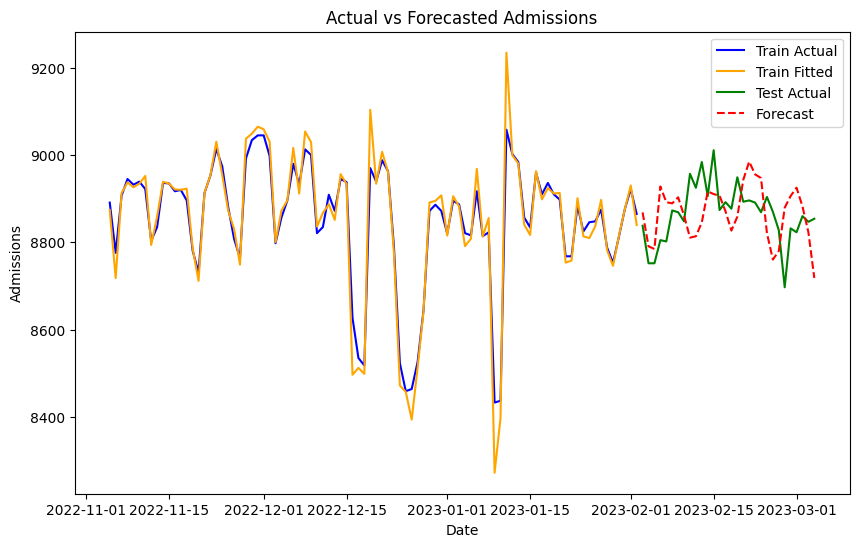

In [11]:
#| hide
from peshbeen.datasets import load_wales_admissions
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
load_wales_admissions["day_of_week"] = load_wales_admissions.index.dayofweek
load_wales_admissions["month"] = load_wales_admissions.index.month
# split the data into train and test sets
train = load_wales_admissions[:-30]
test = load_wales_admissions[-30:]
cat_variables = ["day_of_week", "month"]
# import linear regression from sklearn
from sklearn.linear_model import LinearRegression
ml_linear = ml_forecaster(model=LGBMRegressor(n_estimators=100, verbose=-1),
              target_col='admissions', lags = 14,
              cat_variables=cat_variables)
ml_linear.fit(train)
# ml_linear.data_prep(train)
forecasts = ml_linear.forecast(H=30, exog=test[cat_variables])
ml_linear.predict_in_sample()
## plot actual vs forecasts
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(train.index[-90:], train['admissions'][-90:], label='Train Actual', color='blue')
plt.plot(train.index[-90:], ml_linear.fitted_values[-90:], label='Train Fitted', color='orange')
plt.plot(test.index, test['admissions'], label='Test Actual', color='green')
plt.plot(test.index, forecasts, label='Forecast', color='red', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Admissions')
plt.title('Actual vs Forecasted Admissions')
plt.legend()
plt.show()

In [12]:
#| hide

from peshbeen.metrics import WMAPE, MAE, RMSE
mtrcs = [WMAPE, MAE, RMSE]
cv_results = ml_linear.cross_validate(df=train, cv_split=5, test_size=30, metrics=mtrcs, step_size=30)
cv_results.head()

,cutoff,index,split,y_true,y_pred
0,2022-09-06,2022-09-06,fold_1,8839,8876.810007
1,2022-09-06,2022-09-07,fold_1,8869,8901.109476
2,2022-09-06,2022-09-08,fold_1,8875,8913.652490
3,2022-09-06,2022-09-09,fold_1,8845,8859.044084
4,2022-09-06,2022-09-10,fold_1,8708,8752.088025
